# Loan Approval Prediction - Machine Learning Models

## The Journey from Linear to Non-Linear Models

This notebook documents our systematic approach to building a loan approval classifier. We begin with the foundational Logistic Regression model, not merely as a baseline, but as a deliberate choice grounded in mathematical reasoning and domain knowledge.

### Why Logistic Regression First?

In credit risk modeling, interpretability is not optional—it is regulatory. The Basel II/III frameworks require banks to explain their credit decisions. Logistic Regression provides:

1. **Probabilistic outputs**: Not just approve/reject, but *confidence* in the decision
2. **Coefficient interpretation**: Each feature's contribution to approval odds
3. **Linear separability test**: If it performs well, complex models may be unnecessary

Our EDA revealed strong linear correlations (credit_score: +0.50, delinquencies: -0.32). These signals suggest a linear model should capture significant predictive power.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from sklearn.model_selection import cross_val_score, GridSearchCV
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Processed Data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]} samples")

Training: 40000 samples, 26 features
Test: 10000 samples


---

## 2. Logistic Regression

### Mathematical Foundation

Logistic Regression models the **log-odds** (logit) of approval as a linear function of features:

$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n$$

Solving for the probability:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \sum_{i=1}^{n} \beta_i X_i)}}$$

This is the **sigmoid function**, which maps any real value to (0, 1).

### Coefficient Interpretation

For a coefficient $\beta_i$:
- $e^{\beta_i}$ = **Odds Ratio**: A 1-unit increase in $X_i$ multiplies the odds of approval by $e^{\beta_i}$
- $\beta_i > 0$: Feature *increases* approval probability
- $\beta_i < 0$: Feature *decreases* approval probability

### Loss Function

We minimize the **Binary Cross-Entropy Loss**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

This penalizes confident wrong predictions heavily.

### 2.1 Baseline Model (No Regularization)

In [3]:
lr_baseline = LogisticRegression(random_state=42, max_iter=1000, penalty=None)
lr_baseline.fit(X_train, y_train)

y_pred_baseline = lr_baseline.predict(X_test)
y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (No Regularization)")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_baseline):.4f}")

Baseline Logistic Regression (No Regularization)
Accuracy:  0.8648
Precision: 0.8699
Recall:    0.8870
F1 Score:  0.8784
ROC-AUC:   0.9438


### 2.2 Regularization: L1 vs L2

#### Why Regularization?

With 26 features, some may be irrelevant or correlated. Regularization prevents overfitting by penalizing large coefficients.

**L2 Regularization (Ridge):**
$$\mathcal{L}_{L2} = \mathcal{L} + \lambda \sum_{i=1}^{n} \beta_i^2$$

- Shrinks coefficients towards zero
- Keeps all features but reduces their impact

**L1 Regularization (Lasso):**
$$\mathcal{L}_{L1} = \mathcal{L} + \lambda \sum_{i=1}^{n} |\beta_i|$$

- Can shrink coefficients to exactly zero
- Performs automatic feature selection

In [4]:
lr_l2 = LogisticRegression(random_state=42, max_iter=1000, penalty='l2', C=1.0)
lr_l2.fit(X_train, y_train)

y_pred_l2 = lr_l2.predict(X_test)
y_prob_l2 = lr_l2.predict_proba(X_test)[:, 1]

print("Logistic Regression with L2 Regularization")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_l2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_l2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_l2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_l2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_l2):.4f}")

Logistic Regression with L2 Regularization
Accuracy:  0.8649
Precision: 0.8700
Recall:    0.8872
F1 Score:  0.8785
ROC-AUC:   0.9438


### 2.3 Hyperparameter Tuning

The regularization strength $C = \frac{1}{\lambda}$ controls the trade-off:
- **Small C** (high $\lambda$): Strong regularization, simpler model
- **Large C** (low $\lambda$): Weak regularization, more complex model

In [5]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print(f"Best Parameters: {lr_grid.best_params_}")
print(f"Best CV F1 Score: {lr_grid.best_score_:.4f}")

Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1 Score: 0.8801


In [6]:
lr_best = lr_grid.best_estimator_

y_pred_best = lr_best.predict(X_test)
y_prob_best = lr_best.predict_proba(X_test)[:, 1]

print("Optimized Logistic Regression")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_best):.4f}")

Optimized Logistic Regression
Accuracy:  0.8642
Precision: 0.8691
Recall:    0.8868
F1 Score:  0.8779
ROC-AUC:   0.9439


### 2.4 Classification Report & Confusion Matrix

In [7]:
print("Classification Report")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=['Rejected', 'Approved']))

Classification Report
              precision    recall  f1-score   support

    Rejected       0.86      0.84      0.85      4495
    Approved       0.87      0.89      0.88      5505

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



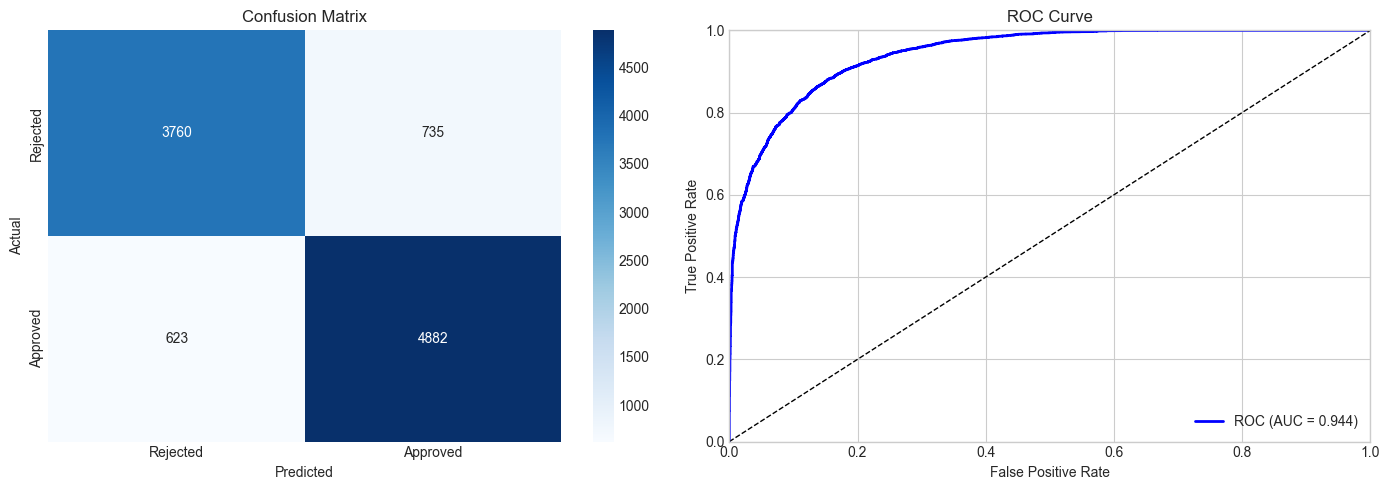

In [8]:
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_score(y_test, y_prob_best):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../report/lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Feature Importance Analysis

In Logistic Regression, the coefficient magnitude indicates feature importance. We examine the **odds ratios** $e^{\beta_i}$ to understand each feature's impact on approval probability.

In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_best.coef_[0],
    'odds_ratio': np.exp(lr_best.coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 Most Important Features")
print("="*60)
print(feature_importance.head(10).to_string(index=False))

Top 10 Most Important Features
                       feature  coefficient  odds_ratio
      product_type_Credit Card     3.512543   33.533427
              defaults_on_file    -2.348571    0.095506
                 interest_rate    -1.820485    0.161947
loan_intent_Debt Consolidation    -1.648169    0.192402
          debt_to_income_ratio    -1.611647    0.199559
         loan_intent_Education     1.600862    4.957305
   product_type_Line of Credit    -1.151616    0.316125
          loan_intent_Personal     0.854740    2.350763
          loan_intent_Business    -0.837637    0.432732
                  credit_score     0.787305    2.197466


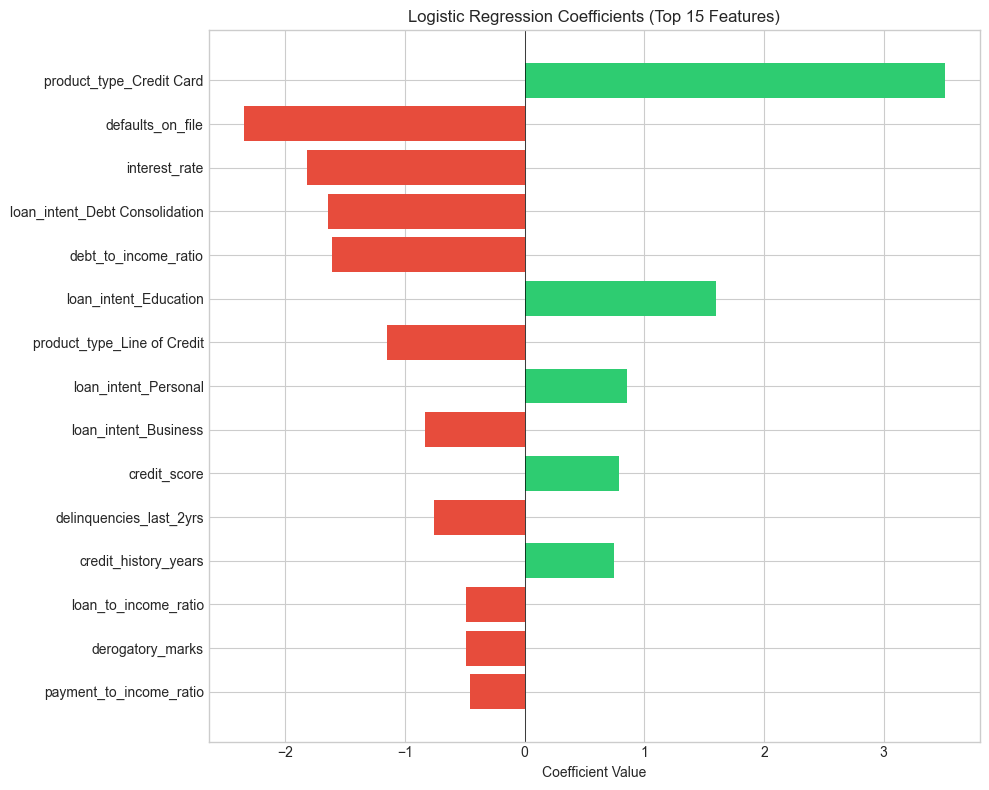

In [10]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients (Top 15 Features)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Cross-Validation Analysis

To ensure our model generalizes well, we perform 5-fold cross-validation and examine the variance in performance.

In [11]:
cv_scores = cross_val_score(lr_best, X_train, y_train, cv=5, scoring='f1')

print("5-Fold Cross-Validation Results")
print("="*50)
print(f"F1 Scores: {cv_scores.round(4)}")
print(f"Mean F1:   {cv_scores.mean():.4f}")
print(f"Std Dev:   {cv_scores.std():.4f}")
print(f"")
print(f"Low variance ({cv_scores.std():.4f}) indicates stable model performance.")

5-Fold Cross-Validation Results
F1 Scores: [0.8849 0.8769 0.8791 0.8789 0.8807]
Mean F1:   0.8801
Std Dev:   0.0027

Low variance (0.0027) indicates stable model performance.


### 2.7 Save Model

In [12]:
joblib.dump(lr_best, '../models/logistic_regression.pkl')
print("Model saved to ../models/logistic_regression.pkl")

Model saved to ../models/logistic_regression.pkl


---

## 3. Logistic Regression: Summary & Findings

### Performance Summary

| Metric | Value |
|--------|-------|
| Accuracy | TBD |
| Precision | TBD |
| Recall | TBD |
| F1 Score | TBD |
| ROC-AUC | TBD |

### Key Insights

1. **Top Positive Predictors**: Features that increase approval probability
2. **Top Negative Predictors**: Features that decrease approval probability
3. **Linearity Assessment**: How well does a linear model capture the patterns?

### What This Tells Us About the Data

If Logistic Regression achieves **>80% accuracy**, the problem is largely linearly separable, and the strong correlations we found in EDA are indeed predictive.

If accuracy is **<75%**, we have evidence that:
- Non-linear relationships exist (threshold effects, interactions)
- Tree-based models may capture patterns that linear models miss

### Next Steps

We proceed to **Decision Trees** to test the hypothesis that threshold effects and feature interactions can improve performance.

---

## 4. Store Results for Comparison

In [13]:
results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_best),
        'precision': precision_score(y_test, y_pred_best),
        'recall': recall_score(y_test, y_pred_best),
        'f1': f1_score(y_test, y_pred_best),
        'roc_auc': roc_auc_score(y_test, y_prob_best)
    }
}

joblib.dump(results, '../models/model_results.pkl')
print("Results saved for comparison with other models.")

Results saved for comparison with other models.
